<a href="https://colab.research.google.com/github/ArnyWu/-Preview-AI-/blob/main/ACE_%E7%8E%8B%E7%89%8C%E9%81%B8%E8%82%A1%E6%B3%95_%E7%B5%90%E5%90%88_K_%E7%B7%9A%E5%9C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 選股

從 ACE 富邦投顧董事長陳奕光列出「ACE王牌選股法」值得關注的個股
1.   刪去國外的股票
2.   從ACE中選出各一個股票 ➡️ 作為我資料集的股票

➡️縮減資料大小，因為共有48隻股票

檔案：ACE_classified_stocks.csv，透過 chatgpt 與人工校對股票名稱與股票編號


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ACE_classified_stocks.csv to ACE_classified_stocks.csv


In [ ]:
import pandas as pd
file_path = '/content/ACE_classified_stocks.csv'
ace_stocks = pd.read_csv(file_path)
ace_stocks.head()

,Category,Company,Stock Code
0,A,力旺,3529.TWO
1,A,台積電,2330.TW
2,A,日月光,3711.TW
3,A,京元電,2449.TW
4,A,智邦,2345.TW


In [ ]:
import yfinance as yf

In [ ]:
# 定義函數來獲取股票基本面數據與當前股價
def get_stock_info(ticker):
    stock = yf.Ticker(ticker)
    info = stock.info
    try:
        close_price = stock.history(period="1d")['Close'].iloc[-1]  # 獲取當前股價
    except Exception as e:
        close_price = None  # 若無法獲取，設為 None 並打印錯誤
        print(f"Failed to fetch price for {ticker}: {e}")
    return {
        "Ticker": ticker,
        "Market Cap": info.get("marketCap"),
        "P/E": info.get("trailingPE"),
        "Revenue Growth": info.get("revenueGrowth"),
        "Dividend Yield": info.get("dividendYield"),
        "Sector": info.get("sector"),
        "Industry": info.get("industry"),
        "Close": close_price  # 添加當前股價
    }

In [ ]:
# 遍歷 ACE 股票列表，提取每支股票的基本面數據
stock_data = []
for ticker in ace_stocks['Stock Code']:
    try:
        stock_data.append(get_stock_info(ticker))
    except Exception as e:
        print(f"Failed to fetch data for {ticker}: {e}")

# 建立一個 DataFrame 存儲基本面數據
stock_df = pd.DataFrame(stock_data)
stock_df

,Ticker,Market Cap,P/E,Revenue Growth,Dividend Yield,Sector,Industry,Close
0,3529.TWO,233321873408,135.105930,0.143,0.0056,Technology,Semiconductors,3125.000000
1,2330.TW,27618325823488,26.276833,0.390,0.0149,Technology,Semiconductors,1065.000000
2,3711.TW,692882374656,19.546570,0.039,0.0330,Technology,Semiconductors,159.500000
3,2449.TW,153453871104,24.042147,-0.181,0.0253,Technology,Semiconductors,125.500000
4,2345.TW,394030153728,40.751446,0.257,0.0141,Technology,Communication Equipment,705.000000
5,3081.TWO,33403691008,NaN,0.078,0.0015,Technology,Semiconductor Equipment & Materials,361.000000
6,3163.TWO,11034117120,23.702421,-0.377,0.0252,Technology,Communication Equipment,137.000000
7,3017.TW,275550896128,37.519787,0.108,0.0102,Technology,Electronic Components,711.000000
8,3324.TWO,64278708224,39.425730,0.208,0.0089,Technology,Computer Hardware,714.000000
9,8996.TW,31323789312,59.860382,-0.235,0.0123,Industrials,Specialty Industrial Machinery,343.000000


In [ ]:
# 合併 ACE 分類和基本面數據
merged_data = ace_stocks.merge(stock_df, left_on='Stock Code', right_on='Ticker')

# 檢查合併後的資料
print("合併後的資料：")
print(merged_data.head())

合併後的資料：
  Category Company Stock Code    Ticker      Market Cap         P/E  \
0        A      力旺   3529.TWO  3529.TWO    233321873408  135.105930   
1        A     台積電    2330.TW   2330.TW  27618325823488   26.276833   
2        A     日月光    3711.TW   3711.TW    692882374656   19.546570   
3        A     京元電    2449.TW   2449.TW    153453871104   24.042147   
4        A      智邦    2345.TW   2345.TW    394030153728   40.751446   

   Revenue Growth  Dividend Yield      Sector                 Industry   Close  
0           0.143          0.0056  Technology           Semiconductors  3125.0  
1           0.390          0.0149  Technology           Semiconductors  1065.0  
2           0.039          0.0330  Technology           Semiconductors   159.5  
3          -0.181          0.0253  Technology           Semiconductors   125.5  
4           0.257          0.0141  Technology  Communication Equipment   705.0  


## A主題（AI應用與基礎建設）
按市值排序，選擇市值靠前且P/E合理的股票。

In [ ]:
# 篩選 A 主題
a_analysis = merged_data[
    (merged_data['Category'] == 'A') &
    (merged_data['P/E'] > 0) & (merged_data['P/E'] < 50) &
    (merged_data['Close'] < 300)
].sort_values(by='Market Cap', ascending=False)

print("A 主題分析結果：")
print(a_analysis[['Company', 'Stock Code', 'Market Cap', 'P/E', 'Close']])

A 主題分析結果：
   Company Stock Code     Market Cap        P/E  Close
12      鴻海    2317.TW  2744576901120  17.522123  198.0
13      廣達    2382.TW  1144792416256  21.305595  297.0
2      日月光    3711.TW   692882374656  19.546570  159.5
14      緯創    3231.TW   344208670720  22.284643  119.0
3      京元電    2449.TW   153453871104  24.042147  125.5
6      波若威   3163.TWO    11034117120  23.702421  137.0


In [ ]:
# 從 A 主題中選擇市值最大的股票
a_selected = a_analysis.head(1)

print("A 主題選擇結果：")
print(a_selected[['Company', 'Stock Code', 'Market Cap', 'P/E', 'Close']])

A 主題選擇結果：
   Company Stock Code     Market Cap        P/E  Close
12      鴻海    2317.TW  2744576901120  17.522123  198.0


## C主題（消費與重建需求）
按營收增長率排序，選擇增長率高且市盈率不過高的股票。

In [ ]:
# 篩選 C 主題
c_analysis = merged_data[
    (merged_data['Category'] == 'C') &
    (merged_data['Revenue Growth'] > 0) & (merged_data['P/E'] < 30)&
    (merged_data['Close'] < 300)
].sort_values(by='Revenue Growth', ascending=False)

print("C 主題分析結果：")
print(c_analysis[['Company', 'Stock Code', 'Revenue Growth', 'P/E', 'Close']])

C 主題分析結果：
   Company Stock Code  Revenue Growth        P/E       Close
26      台泥    1101.TW           0.521  29.051725   33.700001
19      晶技    3042.TW           0.205  17.272726  104.500000
25      宜鼎   5289.TWO           0.135  19.121340  228.500000
20      群光    2385.TW           0.074  12.721146  151.000000
23      華通    2313.TW           0.031  13.515285   61.900002


In [ ]:
# 從 C 主題中選擇營收增長率最高的股票
c_selected = c_analysis.head(1)

print("C 主題選擇結果：")
print(c_selected[['Company', 'Stock Code', 'Revenue Growth', 'P/E', 'Close']])

C 主題選擇結果：
   Company Stock Code  Revenue Growth        P/E      Close
26      台泥    1101.TW           0.521  29.051725  33.700001


## E主題（供電、重電和儲能）
按股利發放率排序，選擇穩定分紅且具增長潛力的股票。

In [ ]:
# 放寬 E 主題篩選條件
e_analysis = merged_data[
    (merged_data['Category'] == 'E') &
    (merged_data['Dividend Yield'] > 0.005) &  # 降低股利門檻
    (merged_data['Revenue Growth'] >= 0) &     # 營收增長率為非負
    (merged_data['Close'] < 400)               # 放寬股價限制
].sort_values(by='Dividend Yield', ascending=False)

print("E 主題分析結果：")
print(e_analysis[['Company', 'Stock Code', 'Dividend Yield', 'Revenue Growth', 'Close']])

E 主題分析結果：
   Company Stock Code  Dividend Yield  Revenue Growth  Close
30     中興電    1513.TW          0.0221           0.244  161.5
33     台達電    2308.TW          0.0164           0.041  399.0


In [ ]:
# 從 E 主題中選擇股利發放率最高的股票
e_selected = e_analysis.head(1)

print("E 主題選擇結果：")
print(e_selected[['Company', 'Stock Code', 'Dividend Yield', 'Revenue Growth', 'Close']])

E 主題選擇結果：
   Company Stock Code  Dividend Yield  Revenue Growth  Close
30     中興電    1513.TW          0.0221           0.244  161.5


In [ ]:
# 合併 A、C、E 主題的選股結果
final_selection = pd.concat([a_selected, c_selected, e_selected], ignore_index=True)

print("最終選股清單：")
print(final_selection[['Company', 'Stock Code', 'Close', 'Market Cap', 'P/E', 'Revenue Growth', 'Dividend Yield']])

最終選股清單：
  Company Stock Code       Close     Market Cap        P/E  Revenue Growth  \
0      鴻海    2317.TW  198.000000  2744576901120  17.522123           0.189   
1      台泥    1101.TW   33.700001   253800775680  29.051725           0.521   
2     中興電    1513.TW  161.500000    79792947200  22.337482           0.244   

   Dividend Yield  
0          0.0255  
1          0.0298  
2          0.0221  


# 下載歷史資料

In [ ]:
!pip install mplfinance

In [ ]:
import yfinance as yf
import pandas as pd
import datetime as dt

# 設定股票代碼、起始和結束日期
stock_ids = ["2317.TW", "1101.TW", "1513.TW"]  # 三檔股票
start = dt.datetime(2017, 5, 1)
end = dt.datetime(2024, 11, 30)

# 下載所有股票數據
all_stock_data = {}

for stock_id in stock_ids:
    # 下載歷史K線數據
    stock_data = yf.download(stock_id, start=start, end=end)
    stock_data.reset_index(inplace=True)
    stock_data["Date"] = pd.to_datetime(stock_data["Date"])
    stock_data.set_index("Date", inplace=True)
    all_stock_data[stock_id] = stock_data
    # 刪除 Ticker 欄位並取代
    stock_data.columns = stock_data.columns.droplevel('Ticker')

# 檢查下載的資料
print("\n歷史K線資料：")
print(all_stock_data["2317.TW"].head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


歷史K線資料：
Price       Adj Close    Close     High     Low     Open    Volume
Date                                                              
2017-05-02  90.582314  125.000  125.625  124.75  124.750  47229600
2017-05-03  91.035217  125.625  126.875  125.00  125.000  34082400
2017-05-04  91.035217  125.625  126.250  125.00  125.625  21939200
2017-05-05  90.582314  125.000  126.250  125.00  125.000  17613600
2017-05-08  91.488144  126.250  126.875  125.00  126.250  16781600

基本面資料：
{'2317.TW': {'PE': 16.283186, 'EPS': 11.3, 'Revenue_Growth': 0.189}, '1101.TW': {'PE': 27.327587, 'EPS': 1.16, 'Revenue_Growth': 0.521}, '1513.TW': {'PE': 21.300138, 'EPS': 7.23, 'Revenue_Growth': 0.244}}


In [ ]:
def add_technical_indicators(data):
    data = data.copy()
    # 移動平均線
    data["5_SMA"] = data["Close"].rolling(window=5).mean()
    data["20_SMA"] = data["Close"].rolling(window=20).mean()
    data["50_SMA"] = data["Close"].rolling(window=50).mean()
    data["200_SMA"] = data["Close"].rolling(window=200).mean()

    # MACD
    data["12_EMA"] = data["Close"].ewm(span=12, adjust=False).mean()
    data["26_EMA"] = data["Close"].ewm(span=26, adjust=False).mean()
    data["MACD"] = data["12_EMA"] - data["26_EMA"]
    data["Signal"] = data["MACD"].ewm(span=9, adjust=False).mean()

    # RSI
    delta = data["Close"].diff()
    gain = delta.where(delta > 0, 0).rolling(window=14).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=14).mean()
    rs = gain / loss
    data["RSI"] = 100 - (100 / (1 + rs))

    # KD值
    high_14 = data["High"].rolling(window=14).max()
    low_14 = data["Low"].rolling(window=14).min()
    data["%K"] = (data["Close"] - low_14) / (high_14 - low_14) * 100
    data["%D"] = data["%K"].rolling(window=3).mean()

    # 成交量波動率：最近14天成交量的標準差與均值比值
    volume_std = data["Volume"].rolling(window=14).std()
    volume_mean = data["Volume"].rolling(window=14).mean()
    data["Volume_Volatility"] = volume_std / volume_mean

    return data


# 加入技術指標
for stock_id in all_stock_data.keys():
    all_stock_data[stock_id] = add_technical_indicators(all_stock_data[stock_id])

# 檢查添加指標後的資料
print("\n添加技術指標後的資料：")
print(all_stock_data["2317.TW"].head())


添加技術指標後的資料：
Price       Adj Close    Close     High     Low     Open    Volume  5_SMA  \
Date                                                                        
2017-05-02  90.582314  125.000  125.625  124.75  124.750  47229600    NaN   
2017-05-03  91.035225  125.625  126.875  125.00  125.000  34082400    NaN   
2017-05-04  91.035225  125.625  126.250  125.00  125.625  21939200    NaN   
2017-05-05  90.582314  125.000  126.250  125.00  125.000  17613600    NaN   
2017-05-08  91.488136  126.250  126.875  125.00  126.250  16781600  125.5   

Price       20_SMA  50_SMA  200_SMA      12_EMA      26_EMA      MACD  \
Date                                                                    
2017-05-02     NaN     NaN      NaN  125.000000  125.000000  0.000000   
2017-05-03     NaN     NaN      NaN  125.096154  125.046296  0.049858   
2017-05-04     NaN     NaN      NaN  125.177515  125.089163  0.088352   
2017-05-05     NaN     NaN      NaN  125.150205  125.082559  0.067646   
2017-05-0

In [ ]:
# 移除含有 NaN 的行
for stock_id in all_stock_data.keys():
    all_stock_data[stock_id] = all_stock_data[stock_id].dropna()

# 檢查移除 NaN 後的數據
print("\n移除 NaN 後的數據：")
all_stock_data["2317.TW"]


移除 NaN 後的數據：


Price,Adj Close,Close,High,Low,Open,Volume,5_SMA,20_SMA,50_SMA,200_SMA,12_EMA,26_EMA,MACD,Signal,RSI,%K,%D,Volume_Volatility
Date,,,,,,,,,,,,,,,,,,
2018-02-21,83.047302,110.250,111.250,110.250,110.250,48363564,110.575,116.11250,116.3100,132.568750,113.112173,115.228550,-2.116377,-1.318158,26.946108,20.192308,15.724654,0.446116
2018-02-22,82.764824,109.875,110.500,109.500,109.750,36470657,110.050,115.76875,116.1175,132.493125,112.614146,114.831991,-2.217845,-1.498095,27.272727,18.000000,17.403666,0.456493
2018-02-23,83.706406,111.125,112.125,110.125,110.125,28335270,110.025,115.46250,116.0150,132.420625,112.385047,114.557399,-2.172352,-1.632947,31.428571,29.166667,22.452991,0.470891
2018-02-26,83.612251,111.000,112.250,111.000,111.250,29605201,110.350,114.95625,115.8950,132.347500,112.171963,114.293888,-2.121925,-1.730742,32.544379,29.032258,25.399642,0.483008
2018-02-27,82.953140,110.125,112.125,110.125,111.875,33272484,110.475,114.42500,115.7575,132.273125,111.857045,113.985081,-2.128036,-1.810201,33.333333,21.505376,26.568100,0.478347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-25,210.500000,210.500,210.500,205.500,206.000,80172067,205.100,210.77500,200.0600,172.837500,207.920089,207.322617,0.597472,2.217568,45.679012,50.000000,22.807018,0.274925
2024-11-26,202.500000,202.500,207.000,202.000,207.000,92584940,204.900,210.15000,200.7300,173.347500,207.086230,206.965386,0.120843,1.798223,38.541667,7.894737,22.807018,0.297294
2024-11-27,196.500000,196.500,201.000,196.500,200.500,92029898,203.000,209.50000,201.2700,173.820000,205.457579,206.190173,-0.732594,1.292060,29.702970,0.000000,19.298246,0.311832


In [ ]:
import numpy as np
import pandas as pd

def compute_label_features(data, future_days=30, return_threshold=0.03, drawdown_threshold=0.05):
    """
    計算未來30天的收益率和風險，並設置標籤。

    :param data: 包含 'Close', 'Low', 'High' 等欄位的 DataFrame
    :param future_days: 預測未來的天數
    :param return_threshold: 收益率的閾值 (正收益的最低要求)
    :param drawdown_threshold: 最大回撤的閾值 (允許的最大風險)
    :return: 包含收益率、最大回撤、風險/收益標籤的 DataFrame
    """
    data = data.copy()

    # 計算未來30天的報酬率
    data['Future_Price'] = data['Close'].shift(-future_days)
    data['Future_Return'] = (data['Future_Price'] - data['Close']) / data['Close']

    # 計算未來30天的最低價和最大回撤
    data['Future_Min'] = data['Low'].rolling(window=future_days).min().shift(-future_days+1)
    data['Max_Drawdown'] = (data['Future_Min'] - data['Close']) / data['Close']

    # 收益標籤：收益為正（1），收益為負（0）
    data['Return_Label'] = np.where(data['Future_Return'] > 0, 1, 0)

    # 風險標籤：低風險（1），高風險（0）
    data['Risk_Label'] = np.where(data['Max_Drawdown'] > -drawdown_threshold, 1, 0)

    # 最終標籤：
    # 1：收益為正且風險低
    # 2：收益為正但風險高
    # 0：收益為負
    data['Final_Label'] = np.where(
        (data['Return_Label'] == 1) & (data['Risk_Label'] == 1), 1,  # 收益正且風險低
        np.where(data['Return_Label'] == 1, 2, 0)  # 收益正但風險高，否則收益負
    )

    # 避免未來無法計算標籤的 NaN 值
    data = data.iloc[:-future_days]  # 去掉最後無法計算的未來標籤行

    return data

In [ ]:
import numpy as np
for stock_id in all_stock_data.keys():
    all_stock_data[stock_id] = compute_label_features(all_stock_data[stock_id])
    all_stock_data[stock_id].dropna(inplace=True)
all_stock_data["2317.TW"]

Price,Adj Close,Close,High,Low,Open,Volume,5_SMA,20_SMA,50_SMA,200_SMA,...,%K,%D,Volume_Volatility,Future_Price,Future_Return,Future_Min,Max_Drawdown,Return_Label,Risk_Label,Final_Label
Date,,,,,,,,,,,,,,,,,,,,,
2018-02-21,83.047302,110.250,111.250,110.250,110.250,48363564,110.575,116.11250,116.3100,132.568750,...,20.192308,15.724654,0.446116,108.750,-0.013605,108.125,-0.019274,0,1,0
2018-02-22,82.764824,109.875,110.500,109.500,109.750,36470657,110.050,115.76875,116.1175,132.493125,...,18.000000,17.403666,0.456493,109.125,-0.006826,108.125,-0.015927,0,1,0
2018-02-23,83.706406,111.125,112.125,110.125,110.125,28335270,110.025,115.46250,116.0150,132.420625,...,29.166667,22.452991,0.470891,108.500,-0.023622,108.125,-0.026997,0,1,0
2018-02-26,83.612251,111.000,112.250,111.000,111.250,29605201,110.350,114.95625,115.8950,132.347500,...,29.032258,25.399642,0.483008,108.750,-0.020270,108.125,-0.025901,0,1,0
2018-02-27,82.953140,110.125,112.125,110.125,111.875,33272484,110.475,114.42500,115.7575,132.273125,...,21.505376,26.568100,0.478347,109.500,-0.005675,108.125,-0.018161,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-11,200.000000,200.000,202.000,199.000,200.000,69936130,196.900,184.57500,182.4900,156.589500,...,93.103448,90.056325,0.380794,210.500,0.052500,196.500,-0.017500,1,1,1
2024-10-14,199.000000,199.000,200.000,196.500,200.000,36211894,197.900,186.07500,182.5500,157.079500,...,88.000000,92.466582,0.389507,202.500,0.017588,196.500,-0.012563,1,1,1
2024-10-15,207.000000,207.000,207.500,200.500,201.000,126315098,199.800,187.95000,182.7300,157.609500,...,98.333333,93.145594,0.429756,196.500,-0.050725,200.500,-0.031401,0,1,0


In [ ]:
def print_label_distribution(data, label_column, period_name):
    labels = data[label_column]
    num_2 = (labels == 2).sum()
    num_1 = (labels == 1).sum()
    num_0 = (labels == 0).sum()
    total = len(labels)
    ratio_2 = num_2 / total if total > 0 else 0
    ratio_1 = num_1 / total if total > 0 else 0
    ratio_0 = num_0 / total if total > 0 else 0
    print(f"{period_name}:")
    print(f"  Label=2的數量（收益正但風險高）：{num_2}, 比例：{ratio_2:.2f}")
    print(f"  Label=1的數量（收益正且風險低）：{num_1}, 比例：{ratio_1:.2f}")
    print(f"  Label=0的數量（收益負）：{num_0}, 比例：{ratio_0:.2f}")
    print("---------------------------")

In [ ]:
import pandas as pd

# 定義時間區間
train_start = pd.to_datetime("2020-01-01")
train_end = pd.to_datetime("2022-12-31")
val_start = pd.to_datetime("2023-01-01")
val_end = pd.to_datetime("2023-12-31")
test_start = pd.to_datetime("2024-01-01")
test_end = pd.to_datetime("2024-12-31")

# 假設 all_stock_data 是包含多支股票資料的字典
# 例如 all_stock_data = {'stock_1': stock_1_df, 'stock_2': stock_2_df, ...}

for stock_id, stock_df in all_stock_data.items():
    # 按時間切分數據
    train_df = stock_df.loc[(stock_df.index >= train_start) & (stock_df.index <= train_end)]
    val_df = stock_df.loc[(stock_df.index >= val_start) & (stock_df.index <= val_end)]
    test_df = stock_df.loc[(stock_df.index >= test_start) & (stock_df.index <= test_end)]

    # 打印各期間的標籤分布
    print(f"股票 {stock_id}:")
    print_label_distribution(train_df, "Final_Label", "2020-2022(訓練集)")
    print_label_distribution(val_df, "Final_Label", "2023(驗證集)")
    print_label_distribution(test_df, "Final_Label", "2024(回測集)")

股票 2317.TW:
2020-2022(訓練集):
  Label=2的數量（收益正但風險高）：52, 比例：0.07
  Label=1的數量（收益正且風險低）：287, 比例：0.39
  Label=0的數量（收益負）：395, 比例：0.54
---------------------------
2023(驗證集):
  Label=2的數量（收益正但風險高）：3, 比例：0.01
  Label=1的數量（收益正且風險低）：113, 比例：0.47
  Label=0的數量（收益負）：123, 比例：0.51
---------------------------
2024(回測集):
  Label=2的數量（收益正但風險高）：39, 比例：0.21
  Label=1的數量（收益正且風險低）：110, 比例：0.58
  Label=0的數量（收益負）：41, 比例：0.22
---------------------------
股票 1101.TW:
2020-2022(訓練集):
  Label=2的數量（收益正但風險高）：31, 比例：0.04
  Label=1的數量（收益正且風險低）：343, 比例：0.47
  Label=0的數量（收益負）：360, 比例：0.49
---------------------------
2023(驗證集):
  Label=2的數量（收益正但風險高）：6, 比例：0.03
  Label=1的數量（收益正且風險低）：89, 比例：0.37
  Label=0的數量（收益負）：144, 比例：0.60
---------------------------
2024(回測集):
  Label=2的數量（收益正但風險高）：4, 比例：0.02
  Label=1的數量（收益正且風險低）：97, 比例：0.51
  Label=0的數量（收益負）：89, 比例：0.47
---------------------------
股票 1513.TW:
2020-2022(訓練集):
  Label=2的數量（收益正但風險高）：137, 比例：0.19
  Label=1的數量（收益正且風險低）：280, 比例：0.38
  Label=0的數量（收益負）：317, 比例：0.43
----------

In [ ]:
# 週、月資料重採樣
def resample_to_weekly(data):
    return data.resample('W').agg({
        'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum',
    })

def resample_to_monthly(data):
    return data.resample('M').agg({
        'Open':'first','High':'max','Low':'min','Close':'last','Volume':'sum',
    })

weekly_stock_data = {}
monthly_stock_data = {}

for stock_id, stock_data in all_stock_data.items():
    weekly_stock_data[stock_id] = resample_to_weekly(stock_data)
    monthly_stock_data[stock_id] = resample_to_monthly(stock_data)

# 檢查週數據
print("\n週數據：")
print(weekly_stock_data["2317.TW"].head())

# 檢查月數據
print("\n月數據：")
print(monthly_stock_data["2317.TW"].head())


週數據：
Price          Open     High      Low    Close     Volume
Date                                                     
2018-02-25  110.250  112.125  109.500  111.125  113169491
2018-03-04  111.250  112.250  108.750  109.750  118937319
2018-03-11  109.625  115.375  108.750  114.875  182209060
2018-03-18  117.375  120.625  115.375  116.000  268521249
2018-03-25  115.750  116.875  113.000  113.000  135084040

月數據：
Price          Open     High      Low    Close     Volume
Date                                                     
2018-02-28  110.250  112.250  109.500  110.125  176047176
2018-03-31  109.750  120.625  108.750  114.250  762164932
2018-04-30  110.625  111.750   99.375  103.625  654077699
2018-05-31  104.125  113.000  100.125  107.125  754671625
2018-06-30  107.750  114.875  100.375  104.000  714022419


<ipython-input-10-d8f50835c741>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return data.resample('M').agg({


In [ ]:
monthly_stock_data["2317.TW"]

Price,Open,High,Low,Close,Volume
Date,,,,,
2018-02-28,110.250,112.250,109.500,110.125,176047176
2018-03-31,109.750,120.625,108.750,114.250,762164932
2018-04-30,110.625,111.750,99.375,103.625,654077699
2018-05-31,104.125,113.000,100.125,107.125,754671625
2018-06-30,107.750,114.875,100.375,104.000,714022419
...,...,...,...,...,...
2024-06-30,177.000,217.500,168.500,214.000,2147957661
2024-07-31,215.000,234.500,188.500,198.000,1939376338
2024-08-31,205.000,205.500,160.000,184.500,2304712205


In [ ]:
import mplfinance as mpf
import numpy as np

# 單根形態判斷
def is_hammer(candle):
    o, h, l, c = candle
    body = abs(c - o)
    total_range = h - l
    lower_shadow = (o if o < c else c) - l
    upper_shadow = h - (c if c > o else o)
    return (body < (total_range * 0.2)) and (lower_shadow > body * 2) and (upper_shadow < body * 1.5)

def is_hanging_man(candle):
    o, h, l, c = candle
    body = abs(c - o)
    total_range = h - l
    lower_shadow = (o if o < c else c) - l
    upper_shadow = h - (c if c > o else o)
    return (body < (total_range * 0.2)) and (lower_shadow < body * 1.5) and (upper_shadow > body * 2)

def is_shooting_star(candle):
    o, h, l, c = candle
    body = abs(c - o)
    total_range = h - l
    lower_shadow = (o if o < c else c) - l
    upper_shadow = h - (c if c > o else o)
    return (body < (total_range * 0.2)) and (upper_shadow > body * 2) and (lower_shadow < body * 1.5)

# 雙根形態判斷
def is_bullish_engulfing(prev_candle, cur_candle):
    po, ph, pl, pc = prev_candle
    co, ch, cl, cc = cur_candle
    return (pc < po) and (cc > co) and (co < pc) and (cc > po)

def is_bearish_engulfing(prev_candle, cur_candle):
    po, ph, pl, pc = prev_candle
    co, ch, cl, cc = cur_candle
    return (pc > po) and (cc < co) and (co > pc) and (cc < po)

def is_piercing_line(prev_candle, cur_candle):
    po, ph, pl, pc = prev_candle
    co, ch, cl, cc = cur_candle
    midpoint = (po + pc) / 2
    return (pc > po) and (co < pc) and (cc > midpoint)

def is_dark_cloud_cover(prev_candle, cur_candle):
    po, ph, pl, pc = prev_candle
    co, ch, cl, cc = cur_candle
    midpoint = (po + pc) / 2
    return (pc < po) and (co > pc) and (cc < midpoint)

# 多根形態判斷 (三根)
def is_morning_star(candles):
    c1, c2, c3 = candles
    return (
        c1[3] < c1[0] and c2[3] > c2[0] and c2[3] > c1[3] and c3[3] > c3[0] and c3[3] > c1[0]
    )

def is_evening_star(candles):
    c1, c2, c3 = candles
    return (
        c1[3] > c1[0] and c2[3] < c2[0] and c2[3] < c1[3] and c3[3] < c3[0] and c3[3] < c1[0]
    )

def is_three_white_soldiers(candles):
    c1, c2, c3 = candles
    return (
        c1[3] > c1[0] and c2[3] > c2[0] and c3[3] > c3[0]  # 每根K線都為陽線
        and c2[0] > c1[3] and c3[0] > c2[3]                # 開盤逐漸抬高
    )

def is_three_black_crows(candles):
    c1, c2, c3 = candles
    return (
        c1[3] < c1[0] and c2[3] < c2[0] and c3[3] < c3[0]  # 每根K線都為陰線
        and c2[0] < c1[3] and c3[0] < c2[3]                # 開盤逐漸降低
    )

def plot_shape_signals(subset):
    O = subset['Open'].values
    H = subset['High'].values
    L = subset['Low'].values
    C = subset['Close'].values

    length = len(subset)
    bull_signals = np.full(length, np.nan)
    bear_signals = np.full(length, np.nan)

    # 信號種類與次數統計
    signal_counts = {"bullish": 0, "bearish": 0}

    # 單根形態偵測
    for i in range(length):
        candle = (O[i], H[i], L[i], C[i])
        if is_hammer(candle):
            bull_signals[i] = H[i] + (H[i] - L[i]) * 0.05
            signal_counts["bullish"] += 1
        if is_hanging_man(candle):
            bear_signals[i] = L[i] - (H[i] - L[i]) * 0.05
            signal_counts["bearish"] += 1
        if is_shooting_star(candle):
            bear_signals[i] = L[i] - (H[i] - L[i]) * 0.05
            signal_counts["bearish"] += 1

    # 雙根形態偵測
    for i in range(1, length):
        prev_candle = (O[i-1], H[i-1], L[i-1], C[i-1])
        cur_candle = (O[i], H[i], L[i], C[i])
        if is_bullish_engulfing(prev_candle, cur_candle):
            bull_signals[i] = H[i] + (H[i] - L[i]) * 0.05
            signal_counts["bullish"] += 1
        if is_bearish_engulfing(prev_candle, cur_candle):
            bear_signals[i] = L[i] - (H[i] - L[i]) * 0.05
            signal_counts["bearish"] += 1
        if is_piercing_line(prev_candle, cur_candle):
            bull_signals[i] = H[i] + (H[i] - L[i]) * 0.05
            signal_counts["bullish"] += 1
        if is_dark_cloud_cover(prev_candle, cur_candle):
            bear_signals[i] = L[i] - (H[i] - L[i]) * 0.05
            signal_counts["bearish"] += 1

    # 多根形態偵測 (三根)
    for i in range(2, length):
        candles = [
            (O[i-2], H[i-2], L[i-2], C[i-2]),
            (O[i-1], H[i-1], L[i-1], C[i-1]),
            (O[i], H[i], L[i], C[i]),
        ]
        if is_morning_star(candles):
            bull_signals[i] = H[i] + (H[i] - L[i]) * 0.05
            signal_counts["bullish"] += 1
        if is_evening_star(candles):
            bear_signals[i] = L[i] - (H[i] - L[i]) * 0.05
            signal_counts["bearish"] += 1
        if is_three_white_soldiers(candles):
            bull_signals[i] = H[i] + (H[i] - L[i]) * 0.05
            signal_counts["bullish"] += 1
        if is_three_black_crows(candles):
            bear_signals[i] = L[i] - (H[i] - L[i]) * 0.05
            signal_counts["bearish"] += 1

    # 去除同一根K線的多重信號
    for i in range(length):
        if not np.isnan(bull_signals[i]) and not np.isnan(bear_signals[i]):
            bull_signals[i] = np.nan  # 優先保留空頭信號

    # 建立 addplot
    addplots = []
    if not np.all(np.isnan(bull_signals)):
        addplots.append(
            mpf.make_addplot(bull_signals, type='scatter', marker='^', color='red', markersize=65, alpha=0.5)
        )
    if not np.all(np.isnan(bear_signals)):
        addplots.append(
            mpf.make_addplot(bear_signals, type='scatter', marker='v', color='green', markersize=65, alpha=0.5)
        )

    # 打印信號統計信息
    #print(f"信號統計: 看多信號次數={signal_counts['bullish']}, 看空信號次數={signal_counts['bearish']}")

    return addplots


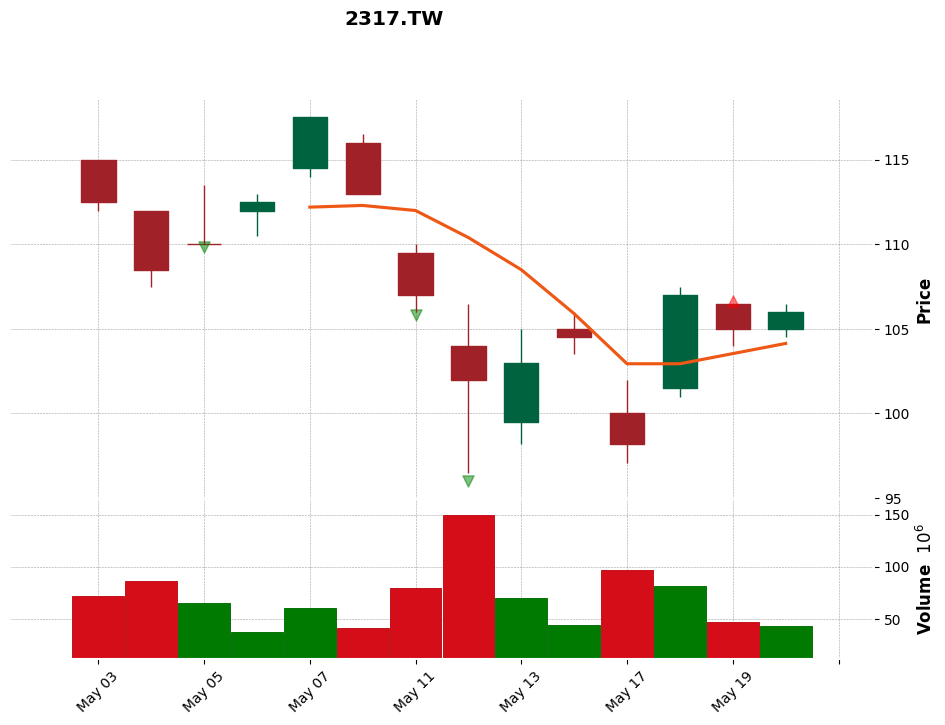

In [ ]:
stock_id = "2317.TW"
data = all_stock_data[stock_id]

# 選擇繪圖範圍
plot_start = "2021-05-01"
plot_end = "2021-05-20"
subset = data.loc[plot_start:plot_end].copy()

if subset.empty:
    print(f"{stock_id}在 {plot_start} 到 {plot_end} 的範圍內沒有可用資料，請嘗試其他日期。")
else:
    # 處理空值
    subset.dropna(inplace=True)

    add_plots = plot_shape_signals(subset)
    mpf.plot(
        subset,
        type='candle',
        style='charles',
        mav=(5,20),
        volume=True,
        addplot=add_plots,
        figsize=(12,8),
        title=f"{stock_id}"
    )

In [ ]:
import os
import mplfinance as mpf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

def initialize_progress_file(progress_file):
    """初始化進度追蹤檔案"""
    if not os.path.exists(progress_file):
        pd.DataFrame(columns=[
            "date", "stock_id", "prefix", "image_path",
            "Close", "5_SMA", "20_SMA", "50_SMA", "200_SMA",
            "RSI", "MACD", "Signal", "%K", "%D", "Volume_Change_Rate", "Final_Label"
        ]).to_csv(progress_file, index=False)

def filter_data_to_align(stock_data, prefix):
    """根據類型篩選對齊資料"""
    target_date = datetime(2020, 1, 2)

    # 根據 prefix 計算起始日期
    if prefix == "daily":
        start_date = target_date - timedelta(days=28)
    elif prefix == "weekly":
        start_date = target_date - timedelta(weeks=19)
    elif prefix == "monthly":
        start_date = target_date - relativedelta(months=20)
    else:
        raise ValueError(f"Unknown prefix: {prefix}")

    # 篩選資料
    filtered_data = stock_data[stock_data.index >= start_date]
    return filtered_data

def save_kline_charts(stock_data, save_path, stock_id, prefix, window, progress_file):
    os.makedirs(save_path, exist_ok=True)
    progress_df = pd.read_csv(progress_file)

    # 篩選已處理的日期
    processed_dates = progress_df[
        (progress_df["stock_id"] == stock_id) & (progress_df["prefix"] == prefix)
    ]["date"].astype(str).tolist()

    # 只處理對齊範圍內的資料
    stock_data = filter_data_to_align(stock_data, prefix)
    print(stock_data.columns)

    # 按照股票編號和日期（索引）排序資料
    stock_data = stock_data.sort_index()

    my_color = mpf.make_marketcolors(up='r', down='g', inherit=True)
    my_style = mpf.make_mpf_style(base_mpf_style='default', marketcolors=my_color)
    image_info = []
    batch_size = 100  # 每 10 次保存一次
    counter = 0      # 計數器初始化

    for i in range(len(stock_data) - window):
        subset = stock_data.iloc[i:i + window]
        last_date = subset.index[-1]
        last_date_str = last_date.strftime('%Y-%m-%d')

        if last_date_str in processed_dates:
            continue

        image_name = f"{stock_id}_{prefix}_{last_date.strftime('%Y%m%d')}.png"
        image_path = os.path.join(save_path, image_name)

        # 繪圖
        shape_addplots = plot_shape_signals(subset)

        mpf.plot(
            subset,
            type='candle',
            style=my_style,
            mav=(5, 20),
            volume=True,
            addplot=shape_addplots,
            savefig=dict(fname=image_path)
        )

        # 提取資訊
        info_dict = {
            "date": last_date_str,
            "stock_id": stock_id,
            "prefix": prefix,
            "image_path": image_path
        }

        if prefix == "daily":
            row = subset.iloc[-1]
            info_dict.update({
                "Close": row["Close"],
                "5_SMA": row.get("5_SMA", np.nan),
                "20_SMA": row.get("20_SMA", np.nan),
                "50_SMA": row.get("50_SMA", np.nan),
                "200_SMA": row.get("200_SMA", np.nan),
                "RSI": row.get("RSI", np.nan),
                "MACD": row.get("MACD", np.nan),
                "Signal": row.get("Signal", np.nan),
                "%K": row.get("%K", np.nan),
                "%D": row.get("%D", np.nan),
                "Volume_Volatility": row.get("Volume_Volatility", np.nan),
                "Label": row.get("Final_Label", np.nan)
            })

        image_info.append(info_dict)

        # 更新計數器
        counter += 1

        # 每處理 100 次，寫入 CSV 並清空暫存數據
        if counter % batch_size == 0:
            print(f"Writing batch of {len(image_info)} entries to {progress_file}")
            new_progress = pd.DataFrame(image_info)
            new_progress.to_csv(progress_file, mode='a', index=False, header=False)
            image_info = []  # 清空暫存數據

    # 保存剩餘數據
    if image_info:
        print(f"Writing final batch of {len(image_info)} entries to {progress_file}")
        new_progress = pd.DataFrame(image_info)
        new_progress.to_csv(progress_file, mode='a', index=False, header=False)

In [ ]:
import zipfile
# 壓縮結果到 ZIP
def compress_to_zip(folder, zip_name):
    with zipfile.ZipFile(zip_name, 'w') as zipf:
        for root, dirs, files in os.walk(folder):
            for file in files:
                zipf.write(os.path.join(root, file), arcname=os.path.join(os.path.basename(root), file))

In [ ]:
# 初始化進度檔案
progress_file = "kline_progress.csv"
initialize_progress_file(progress_file)

# 生成 K 線圖
os.makedirs("./daily_kline", exist_ok=True)
os.makedirs("./weekly_kline", exist_ok=True)
os.makedirs("./monthly_kline", exist_ok=True)

for stock_id, df in all_stock_data.items():
    save_kline_charts(df, "./daily_kline", stock_id, "daily", window=20, progress_file=progress_file)
compress_to_zip("./daily_kline", "daily_kline.zip")
for stock_id, df in weekly_stock_data.items():
    save_kline_charts(df, "./weekly_kline", stock_id, "weekly", window=20, progress_file=progress_file)
compress_to_zip("./weekly_kline", "weekly_kline.zip")
for stock_id, df in monthly_stock_data.items():
    save_kline_charts(df, "./monthly_kline", stock_id, "monthly", window=20, progress_file=progress_file)
compress_to_zip("./monthly_kline", "monthly_kline.zip")
print("K 線圖生成完成，進度已記錄至 CSV。")

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', '5_SMA',
       '20_SMA', '50_SMA', '200_SMA', '12_EMA', '26_EMA', 'MACD', 'Signal',
       'RSI', '%K', '%D', 'Volume_Volatility', 'Future_Price', 'Future_Return',
       'Future_Min', 'Max_Drawdown', 'Return_Label', 'Risk_Label',
       'Final_Label'],
      dtype='object', name='Price')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', '5_SMA',
       '20_SMA', '50_SMA', '200_SMA', '12_EMA', '26_EMA', 'MACD', 'Signal',
       'RSI', '%K', '%D', 'Volume_Volatility', 'Future_Price', 'Future_Return',
       'Future_Min', 'Max_Drawdown', 'Return_Label', 'Risk_Label',
       'Final_Label'],
      dtype='object', name='Price')
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', '5_SMA',
       '20_SMA', '50_SMA', '200_SMA', '12_EMA', '26_EMA', 'MACD', 'Signal',
       'RSI', '%K', '%D', 'Volume_Volatility', 'Future_Price', 'Future_Return',
       'Future_Min', 'Max_Drawdown', 'Return_Label', 'Risk_Label',


In [ ]:
from google.colab import files

# 下載檔案
files.download('/content/kline_progress.csv')
files.download('/content/daily_kline.zip')
files.download('/content/weekly_kline.zip')
files.download('/content/monthly_kline.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# Load the uploaded file to inspect its structure and contents
file_path = 'kline_progress.csv'
kline_data = pd.read_csv(file_path)

# Display the first few rows and basic information about the dataset to analyze its structure
kline_data.head(), kline_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                4410 non-null   object 
 1   stock_id            4410 non-null   object 
 2   prefix              4410 non-null   object 
 3   image_path          4410 non-null   object 
 4   Close               3486 non-null   float64
 5   5_SMA               3486 non-null   float64
 6   20_SMA              3486 non-null   float64
 7   50_SMA              3486 non-null   float64
 8   200_SMA             3486 non-null   float64
 9   RSI                 3486 non-null   float64
 10  MACD                3486 non-null   float64
 11  Signal              3486 non-null   float64
 12  %K                  3486 non-null   float64
 13  %D                  3486 non-null   float64
 14  Volume_Change_Rate  3486 non-null   float64
 15  Final_Label         3486 non-null   float64
dtypes: flo

(         date stock_id prefix                                image_path  \
 0  2020-01-02  2317.TW  daily  ./daily_kline/2317.TW_daily_20200102.png   
 1  2020-01-03  2317.TW  daily  ./daily_kline/2317.TW_daily_20200103.png   
 2  2020-01-06  2317.TW  daily  ./daily_kline/2317.TW_daily_20200106.png   
 3  2020-01-07  2317.TW  daily  ./daily_kline/2317.TW_daily_20200107.png   
 4  2020-01-08  2317.TW  daily  ./daily_kline/2317.TW_daily_20200108.png   
 
        Close      5_SMA     20_SMA  50_SMA  200_SMA        RSI      MACD  \
 0  90.800003  90.960002  91.105001  89.280  80.0660  48.148174  0.577595   
 1  91.599998  91.120001  91.190001  89.502  80.1685  54.838706  0.580069   
 2  90.500000  90.920001  91.190001  89.708  80.2680  41.791043  0.487648   
 3  89.099998  90.560001  91.095000  89.888  80.3535  34.567884  0.298000   
 4  86.500000  89.700000  90.905000  90.002  80.4245  20.201971 -0.061388   
 
      Signal         %K         %D  Volume_Change_Rate  Final_Label  
 0  0.85

In [ ]:
import pandas as pd

# 將 'date' 欄位轉換為 datetime 格式
kline_data['date'] = pd.to_datetime(kline_data['date'])

# 分離日K、周K、月K數據
daily_data = kline_data[kline_data['prefix'] == 'daily']
weekly_data = kline_data[kline_data['prefix'] == 'weekly']
monthly_data = kline_data[kline_data['prefix'] == 'monthly']

# 定義函數來尋找最近的周K數據（符合周邏輯）
def find_nearest_weekly_path(daily_row, weekly_subset):
    stock_data = weekly_subset[weekly_subset['stock_id'] == daily_row['stock_id']]
    if stock_data.empty:
        return None  # 沒有匹配的 stock_id
    # 找到同一周的日期
    stock_data['date_diff'] = (stock_data['date'] - daily_row['date']).abs()
    nearest_row = stock_data.loc[stock_data['date_diff'].idxmin()]
    return nearest_row['image_path']

# 定義函數來尋找最近的月K數據（符合月邏輯）
def find_nearest_monthly_path(daily_row, monthly_subset):
    stock_data = monthly_subset[monthly_subset['stock_id'] == daily_row['stock_id']]
    if stock_data.empty:
        return None  # 沒有匹配的 stock_id
    # 找到最近一個月內的數據
    stock_data = stock_data[stock_data['date'] <= daily_row['date']]
    if stock_data.empty:
        return None  # 沒有過去一個月內的數據
    # 返回日期最接近的記錄
    stock_data['date_diff'] = (daily_row['date'] - stock_data['date']).abs()
    nearest_row = stock_data.loc[stock_data['date_diff'].idxmin()]
    return nearest_row['image_path']

# 將最近的周K和月K圖片路徑新增到每日數據中
daily_data['weekly_image_path'] = daily_data.apply(
    lambda row: find_nearest_weekly_path(row, weekly_data), axis=1
)

daily_data['monthly_image_path'] = daily_data.apply(
    lambda row: find_nearest_monthly_path(row, monthly_data), axis=1
)

# 將更新後的數據存為 CSV 檔案
output_path = 'merged_kline_dataset.csv'
daily_data.to_csv(output_path, index=False)

<ipython-input-3-eeb0ad39eb6d>:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data['weekly_image_path'] = daily_data.apply(
<ipython-input-3-eeb0ad39eb6d>:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_data['monthly_image_path'] = daily_data.apply(


In [ ]:
# 檢查整個 DataFrame 是否有 NaN
print("整個 DataFrame 是否有 NaN：")
print(daily_data.isnull().values.any())

# 查看每個欄位的 NaN 數量
print("\n每個欄位的 NaN 數量：")
print(daily_data.isnull().sum())

# 篩選出包含 NaN 的列
print("\n包含 NaN 的列：")
print(daily_data[daily_data.isnull().any(axis=1)])

# 如果需要進一步處理，這裡提供一些常見的處理方式：
# 1. 移除包含 NaN 的列
# daily_data = daily_data.dropna()

# 2. 用特定值填充 NaN
# daily_data = daily_data.fillna("Unknown")

整個 DataFrame 是否有 NaN：
False

每個欄位的 NaN 數量：
date                  0
stock_id              0
prefix                0
image_path            0
Close                 0
5_SMA                 0
20_SMA                0
50_SMA                0
200_SMA               0
RSI                   0
MACD                  0
Signal                0
%K                    0
%D                    0
Volume_Change_Rate    0
Final_Label           0
weekly_image_path     0
monthly_image_path    0
dtype: int64

包含 NaN 的列：
Empty DataFrame
Columns: [date, stock_id, prefix, image_path, Close, 5_SMA, 20_SMA, 50_SMA, 200_SMA, RSI, MACD, Signal, %K, %D, Volume_Change_Rate, Final_Label, weekly_image_path, monthly_image_path]
Index: []


In [ ]:
!pip install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 5.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# 特徵列表
fixed_features = ['Close']  # 固定選擇部分
sma_features = ['5_SMA', '20_SMA', '50_SMA', '200_SMA']  # SMA 部分
technical_features = ['RSI', 'MACD', 'Signal', '%K', '%D', 'Volume_Change_Rate']  # 技術指標部分

# 分組後的完整特徵
features = fixed_features + sma_features + technical_features

# 計算索引範圍
fixed_start, fixed_end = 0, len(fixed_features)
sma_start, sma_end = fixed_end, fixed_end + len(sma_features)
tech_start, tech_end = sma_end, sma_end + len(technical_features)

# 假設 X 是特徵數據，y 是標籤
X = daily_data[features].fillna(0)  # 填補 NaN
y = daily_data['Final_Label']  # 多分類目標變數（0, 1, 2）

# GA 參數
POP_SIZE = 50
GENS = 20
CX_RATE = 0.7
MUT_RATE = 0.2

selected_feature_sets = set()  # 用於記錄已經選擇的特徵組合

# 評估函數：計算加權 F1 分數
def evaluate(individual):
    # 固定選擇部分
    selected_fixed = [features[i] for i in range(fixed_start, fixed_end) if individual[i] == 1]

    # 第二部分：SMA 特徵
    selected_sma = [features[i] for i in range(sma_start, sma_end) if individual[i] == 1]
    if len(selected_sma) < 2:
        return 0,  # 不符合條件，返回極差值

    # 第三部分：技術指標特徵
    selected_tech = [features[i] for i in range(tech_start, tech_end) if individual[i] == 1]
    if len(selected_tech) < 2:
        return 0,  # 不符合條件，返回極差值

    # 總選擇特徵
    selected_features = selected_fixed + selected_sma + selected_tech
    X_selected = X[selected_features]

    # 分割數據集
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

    # 模型訓練與評估
    model = RandomForestClassifier(random_state=42, n_estimators=200, class_weight="balanced")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # 計算加權 F1 分數
    f1 = f1_score(y_test, y_pred, average="weighted")

    # 多樣性懲罰
    feature_set = tuple(sorted(selected_features))
    diversity_penalty = -0.1 if feature_set in selected_feature_sets else 0  # 已存在組合增加懲罰
    selected_feature_sets.add(feature_set)

    return f1 + diversity_penalty,

# 創建類別
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # 最大化 F1 分數
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_bool", np.random.randint, 0, 2)  # 隨機生成 0 或 1

# 個體生成函數
def generate_individual():
    # 固定選擇第一部分特徵
    individual = [1]  # 固定選中 'Close'

    # 為第二部分 (SMA 特徵) 隨機選擇至少 2 個
    selected_sma = np.random.choice([0, 1], size=len(sma_features), p=[0.5, 0.5])
    while sum(selected_sma) < 2:
        selected_sma = np.random.choice([0, 1], size=len(sma_features), p=[0.5, 0.5])
    individual.extend(selected_sma)

    # 為第三部分 (技術指標特徵) 隨機選擇至少 2 個
    selected_tech = np.random.choice([0, 1], size=len(technical_features), p=[0.5, 0.5])
    while sum(selected_tech) < 2:
        selected_tech = np.random.choice([0, 1], size=len(technical_features), p=[0.5, 0.5])
    individual.extend(selected_tech)

    return individual

toolbox.register("individual", tools.initIterate, creator.Individual, generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", evaluate)

# 初始化種群
population = toolbox.population(n=POP_SIZE)

# Hall of Fame 用於保存最佳個體
hall_of_fame = tools.HallOfFame(1)

# 進化過程記錄
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("std", np.std)
stats.register("min", np.min)
stats.register("max", np.max)

logbook = tools.Logbook()
logbook.header = ["gen", "nevals", "avg", "std", "min", "max", "best_features"]

# 開始進化
for gen in range(GENS):
    offspring = algorithms.varAnd(population, toolbox, cxpb=CX_RATE, mutpb=MUT_RATE)
    fits = map(toolbox.evaluate, offspring)
    for fit, ind in zip(fits, offspring):
        ind.fitness.values = fit

    population = toolbox.select(offspring, k=len(population))
    hall_of_fame.update(population)

    # 紀錄統計數據
    record = stats.compile(population)
    best_ind = tools.selBest(population, k=1)[0]
    best_features = [features[i] for i in range(len(best_ind)) if best_ind[i] == 1]
    logbook.record(gen=gen, nevals=len(population), **record, best_features=best_features)
    print(f"第 {gen} 代最佳特徵：{best_features}，最佳加權 F1 分數：{record['max']:.4f}")

# 最佳結果輸出
best_individual = hall_of_fame[0]
best_features = [features[i] for i in range(len(best_individual)) if best_individual[i] == 1]

print("\n最佳特徵組合：", best_features)
print(f"對應的最佳加權 F1 分數: {best_individual.fitness.values[0]:.4f}")

第 0 代最佳特徵：['Close', '5_SMA', '20_SMA', '200_SMA', 'Signal', '%D']，最佳加權 F1 分數：0.8991
第 1 代最佳特徵：['Close', '5_SMA', '200_SMA', 'Signal', 'Volume_Change_Rate']，最佳加權 F1 分數：0.8930
第 2 代最佳特徵：['Close', '20_SMA', '50_SMA', '200_SMA', 'RSI', 'Signal']，最佳加權 F1 分數：0.8960
第 3 代最佳特徵：['Close', '20_SMA', '50_SMA', '200_SMA', 'RSI', 'MACD', 'Signal']，最佳加權 F1 分數：0.8923
第 4 代最佳特徵：['Close', '5_SMA', '50_SMA', '200_SMA', '%K', '%D']，最佳加權 F1 分數：0.9005
第 5 代最佳特徵：['Close', '5_SMA', '20_SMA', '50_SMA', '200_SMA', '%K', '%D']，最佳加權 F1 分數：0.9044
第 6 代最佳特徵：['Close', '20_SMA', '50_SMA', '200_SMA', 'MACD', '%K']，最佳加權 F1 分數：0.9024
第 7 代最佳特徵：['Close', '5_SMA', '20_SMA', '50_SMA', '200_SMA', 'Signal', '%K', '%D']，最佳加權 F1 分數：0.8987
第 8 代最佳特徵：['Close', '5_SMA', '20_SMA', '50_SMA', '200_SMA', 'Signal', '%K', '%D', 'Volume_Change_Rate']，最佳加權 F1 分數：0.9020
第 9 代最佳特徵：['Close', '5_SMA', '20_SMA', '50_SMA', '200_SMA', 'Signal', '%K', 'Volume_Change_Rate']，最佳加權 F1 分數：0.8977
第 10 代最佳特徵：['Close', '5_SMA', '20_SMA', '50_SMA', '200_

In [ ]:
import pandas as pd

# 讀取資料集
file_path = "/content/merged_kline_dataset.csv"
dataset = pd.read_csv(file_path)

# 保留指定的欄位
columns_to_keep = [
    "date", "stock_id", "prefix", "image_path", "Close",
    "5_SMA", "20_SMA", "50_SMA", "200_SMA", "%K", "%D",
    "Final_Label", "weekly_image_path", "monthly_image_path"
]
filtered_dataset = dataset[columns_to_keep]

# 儲存新的資料集
output_path = "/content/filtered_kline_dataset.csv"
filtered_dataset.to_csv(output_path, index=False)

output_path

'/content/filtered_kline_dataset.csv'

Here

In [ ]:
import shutil

# 定義文件路徑和解壓目標路徑
files = {
    "daily": "/content/daily_kline.zip",
    "weekly": "/content/weekly_kline.zip",
    "monthly": "/content/monthly_kline.zip",
}

# 解壓縮文件
for name, file_path in files.items():
    target_path = f"/content"
    try:
        shutil.unpack_archive(file_path, target_path)
        print(f"{name.capitalize()} K 線解壓成功，目錄: {target_path}")
    except Exception as e:
        print(f"{name.capitalize()} K 線解壓失敗: {e}")

Daily K 線解壓成功，目錄: /content
Weekly K 線解壓成功，目錄: /content
Monthly K 線解壓成功，目錄: /content


In [ ]:
import pandas as pd

# 讀取資料集
file_path = "/content/filtered_kline_dataset.csv"
dataset = pd.read_csv(file_path)

# 將 date 轉為 datetime 格式
dataset['date'] = pd.to_datetime(dataset['date'])
dataset

,date,stock_id,prefix,image_path,Close,5_SMA,20_SMA,50_SMA,200_SMA,%K,%D,Final_Label,weekly_image_path,monthly_image_path
0,2020-01-02,2317.TW,daily,./daily_kline/2317.TW_daily_20200102.png,90.800003,90.960002,91.105001,89.280,80.0660,20.000000,15.198501,0.0,./weekly_kline/2317.TW_weekly_20200105.png,./monthly_kline/2317.TW_monthly_20191231.png
1,2020-01-03,2317.TW,daily,./daily_kline/2317.TW_daily_20200103.png,91.599998,91.120001,91.190001,89.502,80.1685,51.999817,25.587333,0.0,./weekly_kline/2317.TW_weekly_20200105.png,./monthly_kline/2317.TW_monthly_20191231.png
2,2020-01-06,2317.TW,daily,./daily_kline/2317.TW_daily_20200106.png,90.500000,90.920001,91.190001,89.708,80.2680,14.814846,28.938221,0.0,./weekly_kline/2317.TW_weekly_20200105.png,./monthly_kline/2317.TW_monthly_20191231.png
3,2020-01-07,2317.TW,daily,./daily_kline/2317.TW_daily_20200107.png,89.099998,90.560001,91.095000,89.888,80.3535,17.777676,28.197446,0.0,./weekly_kline/2317.TW_weekly_20200105.png,./monthly_kline/2317.TW_monthly_20191231.png
4,2020-01-08,2317.TW,daily,./daily_kline/2317.TW_daily_20200108.png,86.500000,89.700000,90.905000,90.002,80.4245,0.000000,10.864174,0.0,./weekly_kline/2317.TW_weekly_20200105.png,./monthly_kline/2317.TW_monthly_20191231.png
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3481,2024-10-09,1513.TW,daily,./daily_kline/1513.TW_daily_20241009.png,163.000000,165.600000,167.150000,171.090,166.1900,5.263158,17.543860,0.0,./weekly_kline/1513.TW_weekly_20241006.png,./monthly_kline/1513.TW_monthly_20240930.png
3482,2024-10-11,1513.TW,daily,./daily_kline/1513.TW_daily_20241011.png,162.500000,164.200000,167.275000,170.460,166.3725,2.631579,7.017544,1.0,./weekly_kline/1513.TW_weekly_20241013.png,./monthly_kline/1513.TW_monthly_20240930.png
3483,2024-10-14,1513.TW,daily,./daily_kline/1513.TW_daily_20241014.png,165.000000,164.700000,167.825000,169.920,166.5725,15.789474,7.894737,0.0,./weekly_kline/1513.TW_weekly_20241013.png,./monthly_kline/1513.TW_monthly_20240930.png
3484,2024-10-15,1513.TW,daily,./daily_kline/1513.TW_daily_20241015.png,162.500000,163.500000,168.175000,169.390,166.7625,2.631579,7.017544,0.0,./weekly_kline/1513.TW_weekly_20241013.png,./monthly_kline/1513.TW_monthly_20240930.png


In [ ]:
# 資料集劃分
train_data = dataset[(dataset['date'] >= '2020-01-01') & (dataset['date'] <= '2022-12-31')]
val_data = dataset[(dataset['date'] >= '2023-01-01') & (dataset['date'] <= '2023-12-31')]
test_data = dataset[(dataset['date'] >= '2024-01-01')]

# 儲存
train_data.to_csv("/content/train_data.csv", index=False)
val_data.to_csv("/content/val_data.csv", index=False)
test_data.to_csv("/content/test_data.csv", index=False)

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

class MultiModalFeatureExtractor(nn.Module):
    def __init__(self):
        super(MultiModalFeatureExtractor, self).__init__()
        # 每日 K 線的特徵提取器
        self.daily_extractor = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        self.daily_extractor.classifier = nn.Identity()
        self.daily_feature_dim = self.daily_extractor.features[-1][0].out_channels

        # 每周 K 線的特徵提取器（凍結參數）
        self.weekly_extractor = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        self.weekly_extractor.classifier = nn.Identity()
        for param in self.weekly_extractor.parameters():
            param.requires_grad = False

        # 每月 K 線的特徵提取器（凍結參數）
        self.monthly_extractor = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        self.monthly_extractor.classifier = nn.Identity()
        for param in self.monthly_extractor.parameters():
            param.requires_grad = False

        # 自適應融合層
        self.adaptive_fusion = nn.Sequential(
            nn.Linear(self.daily_feature_dim * 3, 256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        # 門控機制：學習周/月特徵的影響程度
        self.gating_layer = nn.Sequential(
            nn.Linear(self.daily_feature_dim * 2, 1),
            nn.Sigmoid()
        )

    def forward(self, daily_input, weekly_input, monthly_input):
        # 提取每日 K 線特徵
        daily_features = self.daily_extractor(daily_input)

        # 提取每周 K 線特徵
        weekly_features = self.weekly_extractor(weekly_input)

        # 提取每月 K 線特徵
        monthly_features = self.monthly_extractor(monthly_input)

        # 門控機制：計算輔助特徵的權重
        weekly_gate = self.gating_layer(torch.cat([daily_features, weekly_features], dim=1))
        monthly_gate = self.gating_layer(torch.cat([daily_features, monthly_features], dim=1))

        # 融合特徵：加權日特徵與輔助特徵
        fused_features = torch.cat([
            daily_features,
            weekly_gate * weekly_features,
            monthly_gate * monthly_features
        ], dim=1)

        # 映射到 128 維
        output = self.adaptive_fusion(fused_features)
        return output

In [ ]:
class LSTMFeatureExtractor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3, dropout=0.5):
        super(LSTMFeatureExtractor, self).__init__()

        self.input_projection = nn.Linear(input_dim, hidden_dim)  # 投影到 hidden_dim

        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0  # 如果只有一層，LSTM 不應該有 dropout
        )

        self.fc = nn.Linear(hidden_dim, output_dim)  # 最後的全連接層

    def forward(self, x):
        if len(x.shape) == 2:  # 如果輸入缺少序列維度
            x = x.unsqueeze(1)  # 添加序列維度，形狀從 [batch_size, features] -> [batch_size, 1, features]

        x = self.input_projection(x)  # 投影到 hidden_dim，形狀 [batch_size, seq_len, hidden_dim]

        x, (hn, cn) = self.lstm(x)  # LSTM，輸出 [batch_size, seq_len, hidden_dim]
        x = hn[-1]  # 使用最後一層的隱藏狀態，形狀 [batch_size, hidden_dim]

        x = self.fc(x)  # 最後輸出到全連接層
        return x

In [ ]:
class BasicFeatureExtractor(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(BasicFeatureExtractor, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [ ]:
class StockPredictionModel(nn.Module):
    def __init__(self, tran_output_dim, basic_output_dim, final_output_dim):
        super(StockPredictionModel, self).__init__()
        self.vit_extractor = MultiModalFeatureExtractor()
        self.tran_extractor = LSTMFeatureExtractor(input_dim=7, hidden_dim=128, output_dim=tran_output_dim)
        self.basic_extractor = BasicFeatureExtractor(input_dim=3, output_dim=basic_output_dim)

        # 對齊層
        self.align_vit = nn.Identity()  # vit_features 保持 128 維
        self.align_tran = nn.Linear(tran_output_dim, 128)  # 將 tran_features 投影到 128 維

        # 注意力機制
        self.attention_1 = nn.MultiheadAttention(embed_dim=128, num_heads=4)
        self.norm_1 = nn.LayerNorm(128)
        self.attention_2 = nn.MultiheadAttention(embed_dim=128, num_heads=4)
        self.norm_2 = nn.LayerNorm(128)

        self.fc = nn.Sequential(
            nn.Linear(128 + basic_output_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, final_output_dim)
        )

    def forward(self, img, weekly_img, monthly_img, tech_indicators, basic_features):
        # 提取特徵
        vit_features = self.vit_extractor(img, weekly_img, monthly_img)
        tran_features = self.tran_extractor(tech_indicators)
        basic_features = self.basic_extractor(basic_features)

        # 投影特徵到相同維度
        vit_features = self.align_vit(vit_features)
        tran_features = self.align_tran(tran_features)

        # 注意力機制交互
        fusion_input = torch.stack([vit_features, tran_features], dim=0)  # [seq_len=2, batch_size, feature_dim=128]
        attn_output_1, _ = self.attention_1(fusion_input, fusion_input, fusion_input)
        attn_output_1 = self.norm_1(attn_output_1 + fusion_input)  # 殘差連接 + 正規化

        attn_output_2, _ = self.attention_2(attn_output_1, attn_output_1, attn_output_1)
        attn_output_2 = self.norm_2(attn_output_2 + attn_output_1)  # 殘差連接 + 正規化

        fusion_features = attn_output_2.mean(dim=0)  # 對 seq_len 維度取平均，形狀 [batch_size, 128]

        # 融合基本面特徵
        combined = torch.cat((fusion_features, basic_features), dim=1)
        return self.fc(combined)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
from torchvision import transforms
from PIL import Image

# 定義圖像轉換
import torchvision.transforms as transforms

image_transforms = transforms.Compose([
    # 先把影像 resize 到 300×300
    transforms.Resize((300, 300)),

    # 轉為 tensor 並將 [0,255] 正規化到 [0,1]
    transforms.ToTensor(),

    # 依照 ImageNet 的統計數據進行標準化
    # mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


def load_image(image_path):
    img = Image.open(image_path).convert("RGB")  # 確保是 RGB 圖像
    return image_transforms(img)

import numpy as np

def prepare_technical_indicators(row):
    indicators = [
        row['Close'],
        row['5_SMA'],
        row['20_SMA'],
        row['50_SMA'],
        row['200_SMA'],
        row['%K'],
        row['%D']
    ]
    return torch.tensor(indicators, dtype=torch.float32)

In [ ]:
import yfinance as yf
import pandas as pd
import datetime as dt

# 設定股票代碼、起始和結束日期
stock_ids = ["2317.TW", "1101.TW", "1513.TW"]  # 三檔股票

# 下載所有股票數據
all_fundamental_data = {}

for stock_id in stock_ids:
    # 獲取基本面數據
    ticker = yf.Ticker(stock_id)
    info = ticker.info  # 基本面資訊

    fundamental_data = {
        "PE": info.get("trailingPE", None),  # 市盈率
        "EPS": info.get("trailingEps", None),  # 每股收益
        "Revenue_Growth": info.get("revenueGrowth", None)  # 營收增長率
    }
    all_fundamental_data[stock_id] = fundamental_data

print("\n基本面資料：")
print(all_fundamental_data)

def get_fundamental_features(stock_id):
    return np.array([all_fundamental_data[stock_id]['PE'], all_fundamental_data[stock_id]['EPS'], all_fundamental_data[stock_id]['Revenue_Growth']], dtype=np.float32)


基本面資料：
{'2317.TW': {'PE': 16.003536, 'EPS': 11.31, 'Revenue_Growth': 0.189}, '1101.TW': {'PE': 27.155172, 'EPS': 1.16, 'Revenue_Growth': 0.521}, '1513.TW': {'PE': 21.784233, 'EPS': 7.23, 'Revenue_Growth': 0.244}}


In [ ]:
from torch.utils.data import Dataset, DataLoader

class StockDataset(Dataset):
    def __init__(self, data, fundamental_data):
        self.data = data
        self.fundamental_data = fundamental_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # 圖像數據
        img = load_image(row['image_path'])  # 日K線
        weekly_img = load_image(row['weekly_image_path'])  # 周K線
        monthly_img = load_image(row['monthly_image_path'])  # 月K線

        # 技術指標
        tech_indicators = prepare_technical_indicators(row)

        # 基本面特徵
        fundamental_features = get_fundamental_features(row['stock_id'])

        # 標籤
        label = int(row['Final_Label'])

        return (img, weekly_img, monthly_img, tech_indicators, fundamental_features, label)


# 建立數據集
train_dataset = StockDataset(train_data, fundamental_data)
val_dataset = StockDataset(val_data, fundamental_data)
test_dataset = StockDataset(test_data, fundamental_data)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# 初始化模型
model = StockPredictionModel(tran_output_dim=64, basic_output_dim=32, final_output_dim=3)
model.to(device)

# 訓練集中各類別樣本數
label_counts = torch.tensor([1072, 910, 220])  # 每類樣本數

# 反比權重計算
class_weights = 1.0 / label_counts.float()

# 正規化，確保權重總和為 1
class_weights /= class_weights.sum()

# 定義損失函數
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

optimizer = optim.Adam(model.parameters(), lr=5e-6, weight_decay=1e-4)

In [ ]:
from sklearn.metrics import f1_score

def train_model(model, train_loader, criterion, optimizer, device):
    model.train()  # 設置模型為訓練模式
    running_loss = 0.0
    all_labels = []  # 用於保存所有真實標籤
    all_preds = []  # 用於保存所有預測標籤

    for batch in train_loader:
        img, weekly_img, monthly_img, tech_indicators, fundamental_features, labels = batch
        img = img.to(device)
        weekly_img = weekly_img.to(device)
        monthly_img = monthly_img.to(device)
        tech_indicators = tech_indicators.to(device)
        fundamental_features = fundamental_features.to(device)
        labels = labels.to(device)

        # 前向傳播
        optimizer.zero_grad()
        outputs = model(img, weekly_img, monthly_img, tech_indicators, fundamental_features)

        # 計算損失
        loss = criterion(outputs, labels)

        # 反向傳播
        loss.backward()
        optimizer.step()

        # 更新損失
        running_loss += loss.item()

        # 記錄真實標籤和預測
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

    # 計算 F1 分數
    f1 = f1_score(all_labels, all_preds, average='weighted')  # 加權 F1 分數

    return running_loss / len(train_loader), f1

In [ ]:
from sklearn.metrics import f1_score, classification_report

def validate_model_with_f1(model, val_loader, criterion, device):
    model.eval()  # 設置模型為驗證模式
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []  # 用於保存所有真實標籤
    all_preds = []  # 用於保存所有預測標籤

    with torch.no_grad():
        for batch in val_loader:
            img, weekly_img, monthly_img, tech_indicators, fundamental_features, labels = batch
            img = img.to(device)
            weekly_img = weekly_img.to(device)
            monthly_img = monthly_img.to(device)
            tech_indicators = tech_indicators.to(device)
            fundamental_features = fundamental_features.to(device)
            labels = labels.to(device)

            # 前向傳播
            outputs = model(img, weekly_img, monthly_img, tech_indicators, fundamental_features)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # 記錄真實標籤和預測
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

            # 計算準確率
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # 計算加權 F1 分數
    f1 = f1_score(all_labels, all_preds, average='weighted')  # 加權 F1 分數
    report = classification_report(all_labels, all_preds, target_names=['Label 0', 'Label 1', 'Label 2'])

    accuracy = correct / total
    return running_loss / len(val_loader), accuracy, f1, report

In [ ]:
import torch
from torch import optim

# 設定早停參數
early_stopping_patience = 6
best_val_loss = float('inf')  # 用於追蹤最好的驗證損失
no_improve_epochs = 0  # 記錄未改進的 epoch 數
best_model_path = "best_model.pth"  # 儲存最佳模型的路徑

# 學習率調度器
num_epochs = 50
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda epoch: (1 - epoch / num_epochs) ** 0.9)


for epoch in range(num_epochs):
    # 訓練模型
    train_loss, train_f1 = train_model(model, train_loader, criterion, optimizer, device)

    # 驗證模型
    val_loss, val_accuracy, val_f1, val_report = validate_model_with_f1(model, val_loader, criterion, device)

    # 打印訓練與驗證結果
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}, Val F1: {val_f1:.4f}")
    print("Validation Classification Report:")
    print(val_report)

    # 顯示目前學習率
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current learning rate: {current_lr:.12f}")

    # 調整學習率
    scheduler.step()

    # 檢查是否為最佳模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_epochs = 0  # 重置早停計數器
        torch.save(model.state_dict(), best_model_path)  # 保存最佳模型
        print(f"New best model saved at epoch {epoch+1} with val_loss: {val_loss:.4f}")
    else:
        no_improve_epochs += 1  # 未改進的 epoch 加 1

    # 檢查是否早停
    if no_improve_epochs >= early_stopping_patience:
        print("Early stopping triggered!")
        break

Epoch 1/50
Train Loss: 1.1210, Train F1: 0.2561
Val Loss: 1.1899, Val Accuracy: 0.2748, Val F1: 0.2587
Validation Classification Report:
              precision    recall  f1-score   support

     Label 0       0.47      0.46      0.47       363
     Label 1       0.62      0.02      0.03       305
     Label 2       0.07      0.49      0.12        49

    accuracy                           0.27       717
   macro avg       0.39      0.32      0.21       717
weighted avg       0.51      0.27      0.26       717

Current learning rate: 0.000005000000
New best model saved at epoch 1 with val_loss: 1.1899
Epoch 2/50
Train Loss: 1.1040, Train F1: 0.3057
Val Loss: 1.1686, Val Accuracy: 0.2887, Val F1: 0.2770
Validation Classification Report:
              precision    recall  f1-score   support

     Label 0       0.47      0.50      0.48       363
     Label 1       0.62      0.03      0.06       305
     Label 2       0.05      0.29      0.08        49

    accuracy                       

<ipython-input-14-afac417b59ed>:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Loaded the best model from training.


NameError: name 'files' is not defined

In [ ]:
# 加載最佳模型進行測試或部署
best_model_path = "best_model.pth"  # 儲存最佳模型的路徑
model.load_state_dict(torch.load(best_model_path))
print("Loaded the best model from training.")

<ipython-input-16-d8d5625ee726>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Loaded the best model from training.


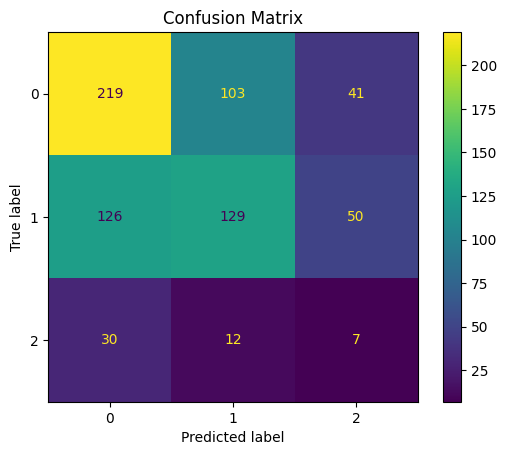

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# 獲取真實標籤與預測值
y_true, y_pred = [], []
with torch.no_grad():
    for batch in val_loader:
        img = batch[0].to(device)
        weekly_img = batch[1].to(device)
        monthly_img = batch[2].to(device)
        tech_indicators = batch[3].to(device)
        fundamental_features = batch[4].to(device)
        labels = batch[5].to(device)
        outputs = model(img, weekly_img, monthly_img, tech_indicators, fundamental_features)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 混淆矩陣
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="viridis")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
all_predictions = []
all_labels = []
all_indices = test_data.index.tolist()  # 直接使用測試集的索引

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        img = batch[0].to(device)
        weekly_img = batch[1].to(device)
        monthly_img = batch[2].to(device)
        tech_indicators = batch[3].to(device)
        fundamental_features = batch[4].to(device)
        labels = batch[5].to(device)

        # 模型推理
        outputs = model(img, weekly_img, monthly_img, tech_indicators, fundamental_features)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

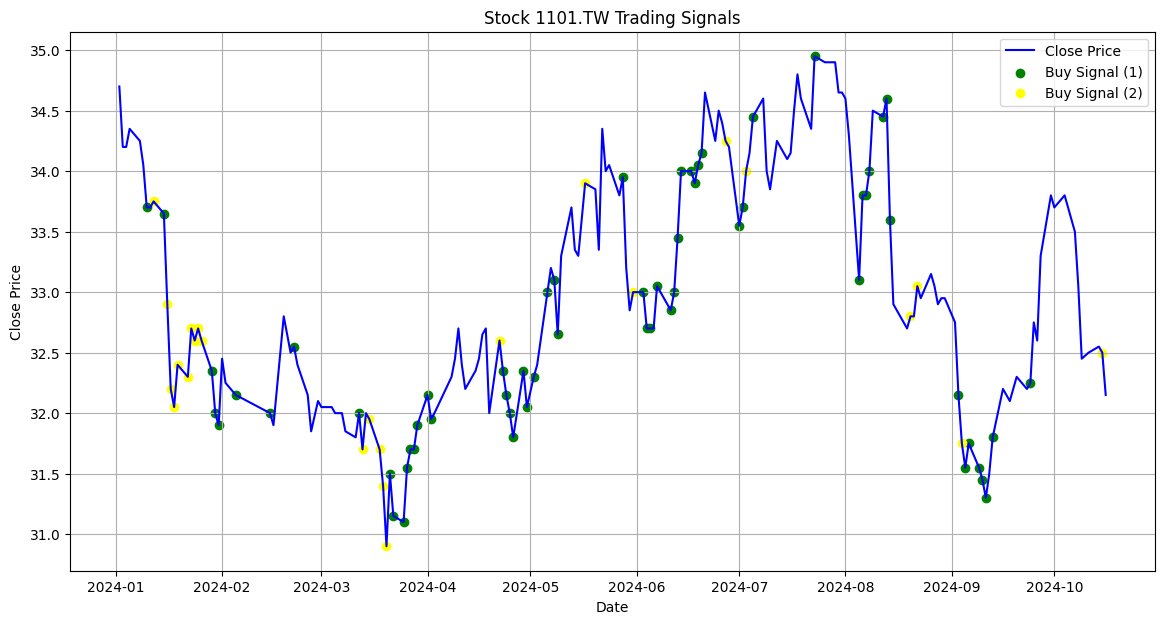

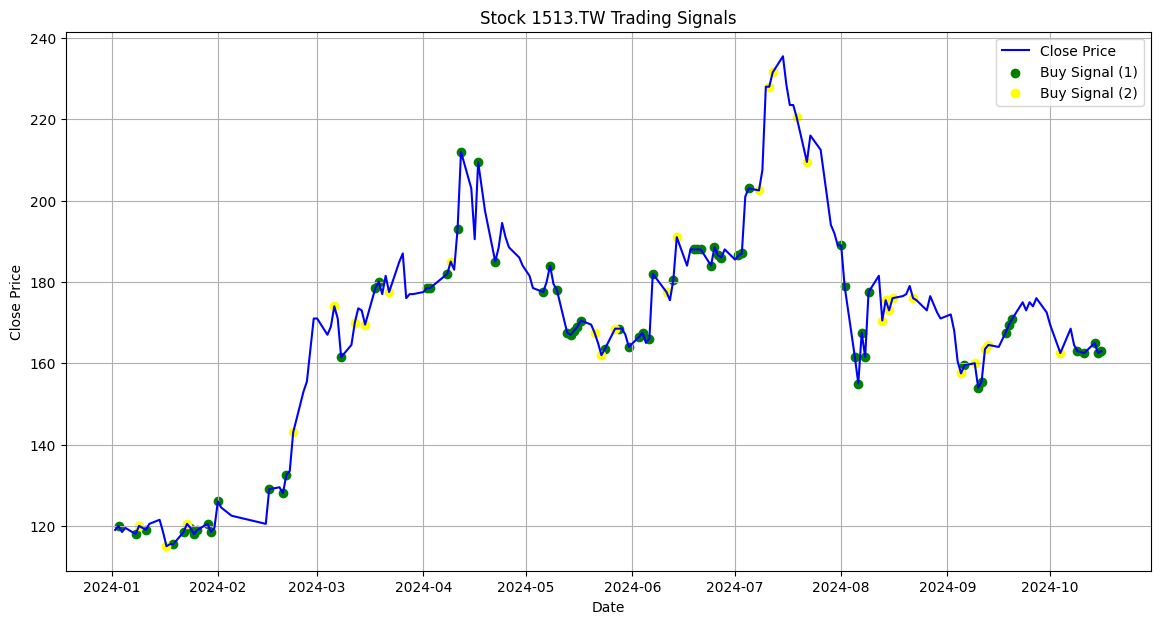

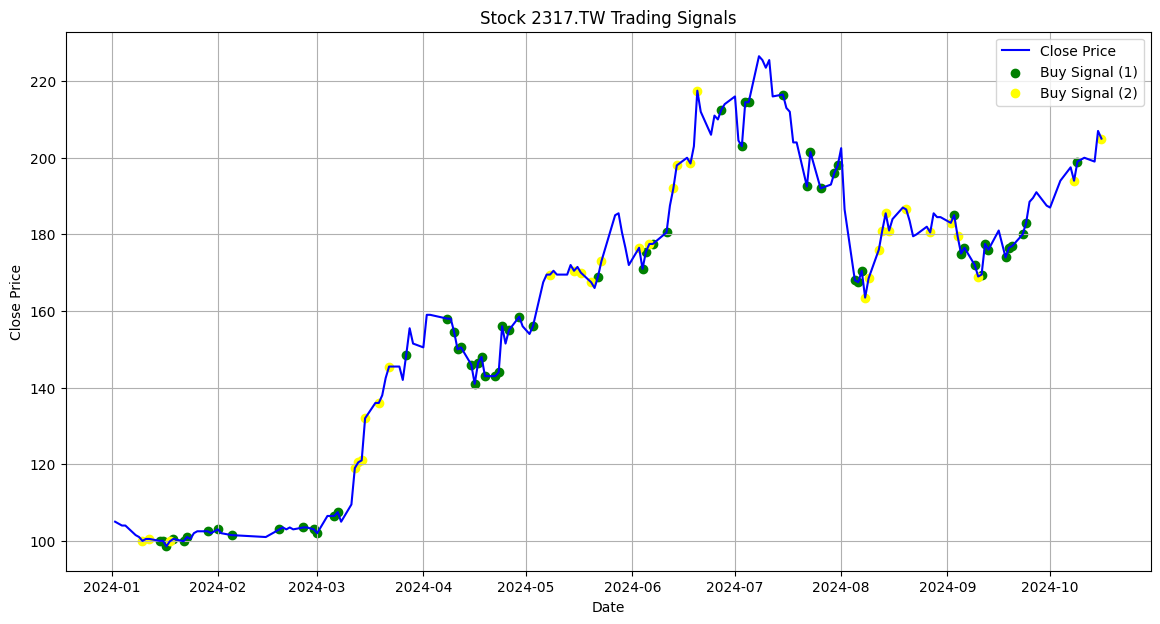

Stock 1101.TW Results:
  Signal=1 - Total Trades: 52, Profitable Trades: 4, Profitability: 7.69%
  Signal=2 - Total Trades: 22, Profitable Trades: 1, Profitability: 4.55%
  Final Portfolio Value: 66659.20 元
  Net Profit/Loss: -33340.80 元

Stock 1513.TW Results:
  Signal=1 - Total Trades: 57, Profitable Trades: 29, Profitability: 50.88%
  Signal=2 - Total Trades: 24, Profitable Trades: 11, Profitability: 45.83%
  Final Portfolio Value: 144040.35 元
  Net Profit/Loss: 44040.35 元

Stock 2317.TW Results:
  Signal=1 - Total Trades: 49, Profitable Trades: 35, Profitability: 71.43%
  Signal=2 - Total Trades: 28, Profitable Trades: 18, Profitability: 64.29%
  Final Portfolio Value: 182343.88 元
  Net Profit/Loss: 82343.88 元



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 初始資金設定
initial_capital = 100000  # 每支股票的初始資金（單位：元）
transaction_fee = 0.03  # 每次交易的手續費
allocation_ratio = 0.1  # 每次交易使用資金的比例

# 將 all_predictions 與 test_data 的索引對應
predictions_series = pd.Series(all_predictions, index=test_data.index)

# 分組回測
grouped = test_data.groupby("stock_id")

# 儲存每支股票的結果
stock_results = {}

for stock_id, group in grouped:
    # 初始化每支股票的資金與結果
    portfolio_value = initial_capital
    cash_balance = initial_capital  # 可用資金
    results = {"Signal=1": {"total_trades": 0, "profitable_trades": 0},
               "Signal=2": {"total_trades": 0, "profitable_trades": 0}}

    backtest_df = pd.DataFrame({
        "Date": group["date"],
        "Close": group["Close"],
        "Signal": predictions_series[group.index]
    })

    # 計算未來30天的收益率
    backtest_df["Future_Return"] = backtest_df["Close"].shift(-30) / backtest_df["Close"] - 1
    backtest_df["Shares"] = 0  # 記錄每次交易的股數

    for idx in backtest_df.index:
        signal = backtest_df.loc[idx, "Signal"]
        if pd.isna(backtest_df.loc[idx, "Future_Return"]):  # 避免超出數據範圍
            continue

        if signal in [1, 2]:
            stock_price = backtest_df.loc[idx, "Close"]
            trade_return = backtest_df.loc[idx, "Future_Return"]

            # 計算此次可用資金
            trade_capital = cash_balance * allocation_ratio
            shares_to_buy = int(trade_capital / stock_price)
            if shares_to_buy == 0:
                continue  # 資金不足，跳過交易

            # 計算交易總花費和收益
            buy_cost = shares_to_buy * stock_price * (1 + transaction_fee)  # 買入成本
            sell_value = shares_to_buy * stock_price * (1 + trade_return) * (1 - transaction_fee)  # 賣出收益
            profit_loss = sell_value - buy_cost  # 盈虧

            # 更新資金
            cash_balance -= buy_cost  # 扣除買入成本
            cash_balance += sell_value  # 增加賣出收益
            portfolio_value = cash_balance  # 更新投資組合價值

            # 更新交易統計
            trade_type = f"Signal={signal}"
            results[trade_type]["total_trades"] += 1
            if profit_loss > 0:
                results[trade_type]["profitable_trades"] += 1

    # 保存每支股票的結果
    stock_results[stock_id] = {
        "results": results,
        "final_portfolio_value": portfolio_value
    }

    # 繪製交易信號與股價走勢
    plt.figure(figsize=(14, 7))
    plt.plot(backtest_df["Date"], backtest_df["Close"], label="Close Price", color="blue")
    plt.scatter(
        backtest_df[backtest_df["Signal"] == 1]["Date"],
        backtest_df[backtest_df["Signal"] == 1]["Close"],
        label="Buy Signal (1)", color="green", marker="o"
    )
    plt.scatter(
        backtest_df[backtest_df["Signal"] == 2]["Date"],
        backtest_df[backtest_df["Signal"] == 2]["Close"],
        label="Buy Signal (2)", color="yellow", marker="o"
    )
    plt.title(f"Stock {stock_id} Trading Signals")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid()
    plt.show()

# 輸出每支股票的結果
for stock_id, metrics in stock_results.items():
    final_value = metrics["final_portfolio_value"]
    profit_loss = final_value - initial_capital  # 計算純收益
    print(f"Stock {stock_id} Results:")
    for signal_type, data in metrics["results"].items():
        total_trades = data["total_trades"]
        profitable_trades = data["profitable_trades"]
        profitability = (profitable_trades / total_trades) * 100 if total_trades > 0 else 0
        print(f"  {signal_type} - Total Trades: {total_trades}, Profitable Trades: {profitable_trades}, Profitability: {profitability:.2f}%")
    print(f"  Final Portfolio Value: {final_value:.2f} 元")
    print(f"  Net Profit/Loss: {profit_loss:.2f} 元\n")  # 顯示純收益或損失


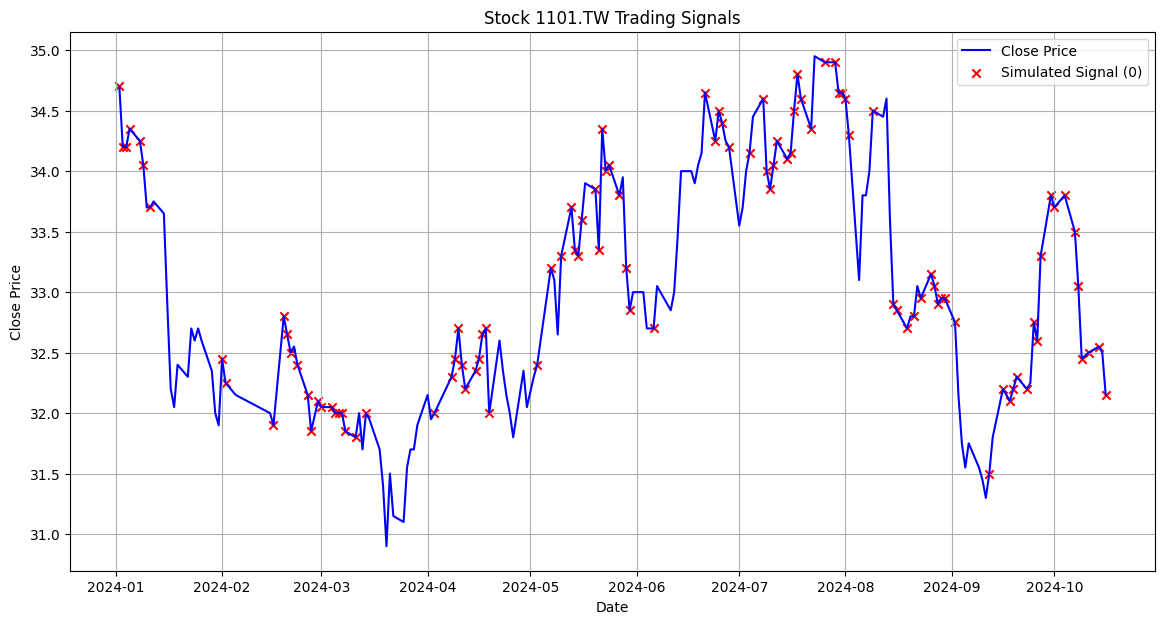

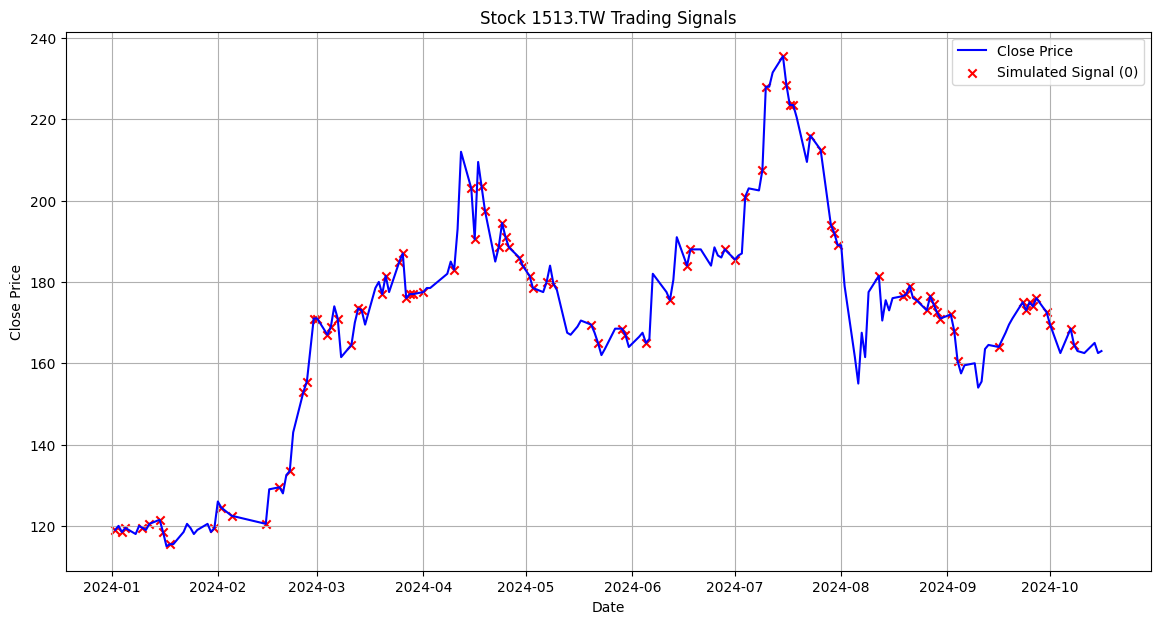

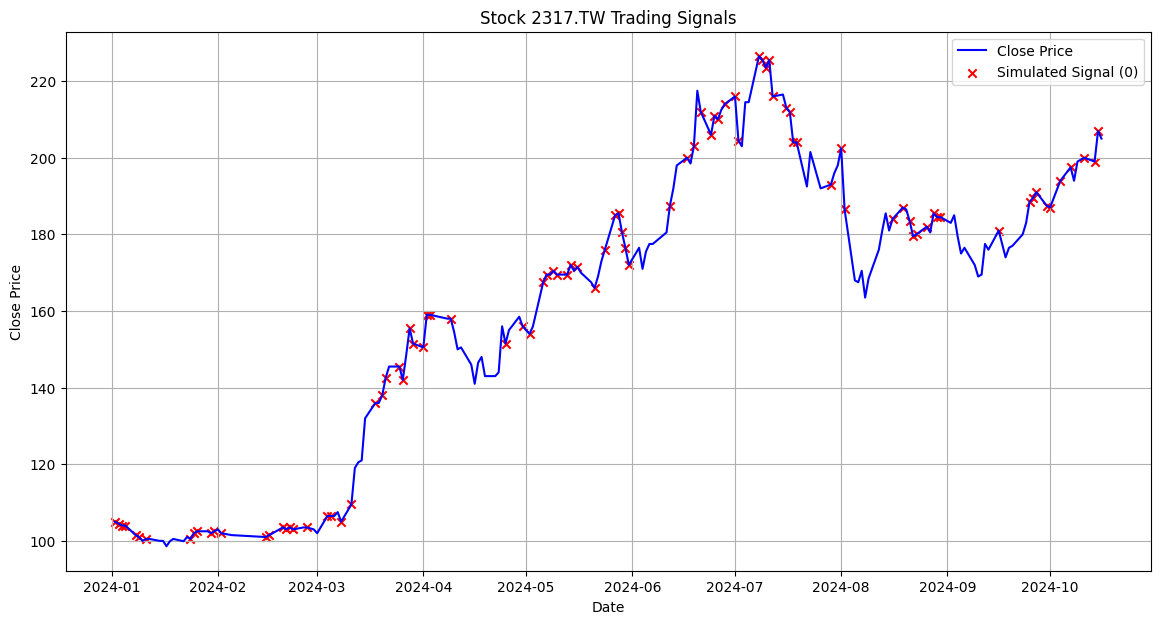

Stock 1101.TW Results:
  Signal=0 - Total Trades: 85, Profitable Trades: 0, Profitability: 0.00%
  Final Portfolio Value: 55785.31 元
  Net Profit/Loss: -44214.69 元

Stock 1513.TW Results:
  Signal=0 - Total Trades: 78, Profitable Trades: 30, Profitability: 38.46%
  Final Portfolio Value: 94108.98 元
  Net Profit/Loss: -5891.02 元

Stock 2317.TW Results:
  Signal=0 - Total Trades: 82, Profitable Trades: 50, Profitability: 60.98%
  Final Portfolio Value: 165553.39 元
  Net Profit/Loss: 65553.39 元



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 初始資金設定
initial_capital = 100000  # 每支股票的初始資金（單位：元）
transaction_fee = 0.03  # 每次交易的手續費
allocation_ratio = 0.1  # 每次交易使用資金的比例

# 將 all_predictions 與 test_data 的索引對應
predictions_series = pd.Series(all_predictions, index=test_data.index)

# 分組回測
grouped = test_data.groupby("stock_id")

# 儲存每支股票的結果
stock_results = {}

for stock_id, group in grouped:
    # 初始化每支股票的資金與結果
    portfolio_value = initial_capital
    cash_balance = initial_capital  # 可用資金
    results = {"Signal=0": {"total_trades": 0, "profitable_trades": 0}}

    backtest_df = pd.DataFrame({
        "Date": group["date"],
        "Close": group["Close"],
        "Signal": predictions_series[group.index]
    })

    # 計算未來30天的收益率
    backtest_df["Future_Return"] = backtest_df["Close"].shift(-30) / backtest_df["Close"] - 1
    backtest_df["Shares"] = 0  # 記錄每次交易的股數

    for idx in backtest_df.index:
        signal = backtest_df.loc[idx, "Signal"]
        if pd.isna(backtest_df.loc[idx, "Future_Return"]):  # 避免超出數據範圍
            continue

        if signal == 0:  # 僅處理 Signal=0 的情況
            stock_price = backtest_df.loc[idx, "Close"]
            trade_return = backtest_df.loc[idx, "Future_Return"]

            # 計算此次可用資金
            trade_capital = cash_balance * allocation_ratio
            shares_to_buy = int(trade_capital / stock_price)
            if shares_to_buy == 0:
                continue  # 資金不足，跳過交易

            # 計算交易總花費和收益
            buy_cost = shares_to_buy * stock_price * (1 + transaction_fee)  # 買入成本
            sell_value = shares_to_buy * stock_price * (1 + trade_return) * (1 - transaction_fee)  # 賣出收益
            profit_loss = sell_value - buy_cost  # 盈虧

            # 更新資金
            cash_balance -= buy_cost  # 扣除買入成本
            cash_balance += sell_value  # 增加賣出收益
            portfolio_value = cash_balance  # 更新投資組合價值

            # 更新交易統計
            trade_type = "Signal=0"
            results[trade_type]["total_trades"] += 1
            if profit_loss > 0:
                results[trade_type]["profitable_trades"] += 1

    # 保存每支股票的結果
    stock_results[stock_id] = {
        "results": results,
        "final_portfolio_value": portfolio_value
    }

    # 繪製交易信號與股價走勢
    plt.figure(figsize=(14, 7))
    plt.plot(backtest_df["Date"], backtest_df["Close"], label="Close Price", color="blue")
    plt.scatter(
        backtest_df[backtest_df["Signal"] == 0]["Date"],
        backtest_df[backtest_df["Signal"] == 0]["Close"],
        label="Simulated Signal (0)", color="red", marker="x"
    )
    plt.title(f"Stock {stock_id} Trading Signals")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.legend()
    plt.grid()
    plt.show()

# 輸出每支股票的結果
for stock_id, metrics in stock_results.items():
    final_value = metrics["final_portfolio_value"]
    profit_loss = final_value - initial_capital  # 計算純收益
    print(f"Stock {stock_id} Results:")
    for signal_type, data in metrics["results"].items():
        total_trades = data["total_trades"]
        profitable_trades = data["profitable_trades"]
        profitability = (profitable_trades / total_trades) * 100 if total_trades > 0 else 0
        print(f"  {signal_type} - Total Trades: {total_trades}, Profitable Trades: {profitable_trades}, Profitability: {profitability:.2f}%")
    print(f"  Final Portfolio Value: {final_value:.2f} 元")
    print(f"  Net Profit/Loss: {profit_loss:.2f} 元\n")  # 顯示純收益或損失